# Misure rilevanti su un grafo diretto con NetworkX

Questo notebook mostra **solo le misure più utili** per analizzare un **grafo diretto** costruito da una *edge list* e indica **quando una misura è dispendiosa** per grafi grandi.

> **Nota:** per grafi molto grandi, alcune misure basate su cammini minimi o enumerazione di cicli possono diventare impraticabili.


## 0) Setup e costruzione del grafo

Assumiamo di avere una lista di archi orientati:

- `edges = [(u1, v1), (u2, v2), ...]`

Sostituisci/leggi i dati nel modo che preferisci (CSV, JSON, ecc.).

In [1]:
# =============================================
# FAST LOAD: FILTERED GRAPH + PREPROCESSING INFO
# =============================================
# Use this cell to quickly load the pre-filtered graph
# AND the preprocessing info (channel English message counts)
#
# Requirements: run the full filtering cell ONCE first to create the cache files

import pandas as pd
import networkx as nx
import json

FILTERED_EDGES_FILE = '../../material/tgdataset_edges_filtered.csv.gz'
VALID_CHANNELS_CACHE = '../../material/valid_channels_cache.json'

# Load filtered edges
print("Loading filtered edges...")
edges_df = pd.read_csv(FILTERED_EDGES_FILE, compression='gzip')
G = nx.DiGraph()
G.add_edges_from(zip(edges_df['source'], edges_df['target']))

# Load preprocessing info
print("Loading preprocessing info...")
with open(VALID_CHANNELS_CACHE, 'r') as f:
    cache_data = json.load(f)

valid_channels = set(cache_data['valid_channel_ids'])
channel_english_count = {int(k): v for k, v in cache_data['channel_english_count'].items()}
MIN_CHANNEL_MESSAGES = cache_data['min_channel_messages']

print(f"\n{'='*60}")
print(f"FILTERED GRAPH LOADED")
print(f"{'='*60}")
print(f"  Edges: {len(edges_df):,}")
print(f"  Nodes: {G.number_of_nodes():,}")
print(f"  Valid channels: {len(valid_channels):,}")
print(f"  Min English messages: {MIN_CHANNEL_MESSAGES}")

Caricati 6,955,167 archi, 1,117,812 nodi


## 1) Dimensione e densità (sempre fattibili)

- **Numero di nodi**: `G.number_of_nodes()`
- **Numero di archi**: `G.number_of_edges()`
- **Densità**: `nx.density(G)`

**Costo:** ~O(1)

In [2]:
n = G.number_of_nodes()
m = G.number_of_edges()
dens = nx.density(G)

n, m, dens

(1117812, 6955167, 5.566348786247016e-06)

## 2) In-degree e out-degree (fondamentali)

- **In-degree**: numero di archi entranti
- **Out-degree**: numero di archi uscenti

**Costo:** ~O(|E|) (scala bene anche su grafi grandi)

In [8]:
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Top-10 per in-degree / out-degree
top_in  = sorted(in_deg.items(),  key=lambda x: x[1], reverse=True)[:10]
top_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:10]

top_in, top_out

([(1303782697, 2970),
  (1145761925, 2455),
  (1102334403, 2287),
  (1225656516, 2020),
  (1004035975, 1957),
  (1133019113, 1846),
  (1241034426, 1761),
  (1334602589, 1755),
  (1335904171, 1730),
  (1440393212, 1604)],
 [(1394050290, 6172),
  (1117628569, 5740),
  (1101170442, 5601),
  (200389711, 4808),
  (1179270258, 4379),
  (1069772626, 4269),
  (1096463945, 4194),
  (1479163323, 3761),
  (1378813139, 3759),
  (1036362176, 3688)])

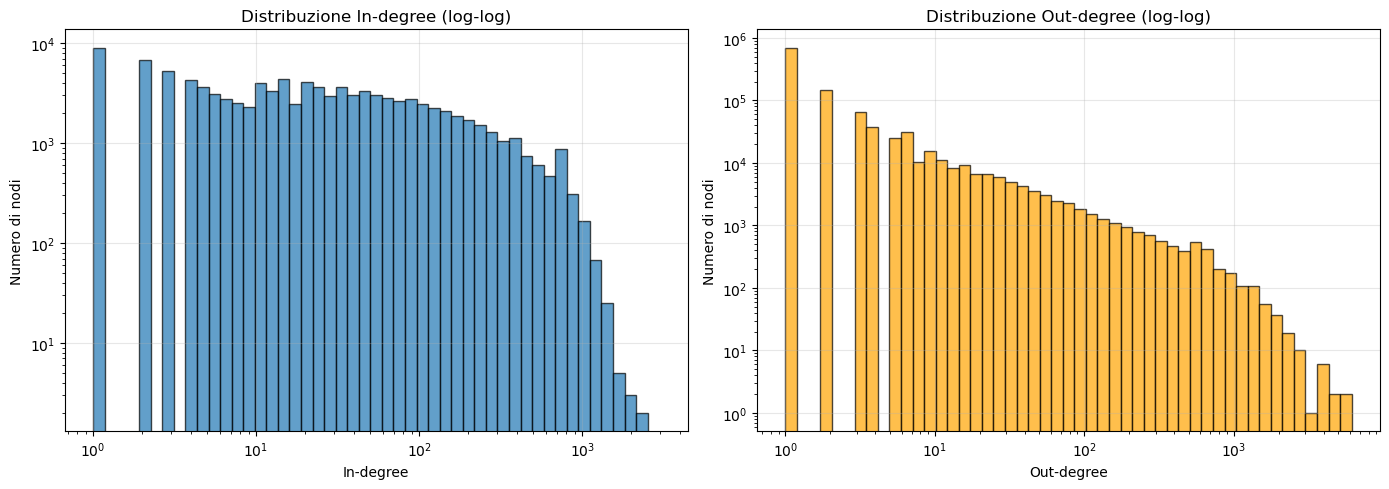

STATISTICHE IN-DEGREE
Nodi con in-degree = 0:   1,013,414 (90.7%)
Nodi con in-degree < 10:  1,053,033 (94.2%)
Nodi con in-degree < 100: 1,099,642 (98.4%)
Nodi con in-degree >= 100: 18,170 (1.6%)

STATISTICHE OUT-DEGREE
Nodi con out-degree = 0:   3,000 (0.3%)
Nodi con out-degree < 10:  1,031,461 (92.3%)
Nodi con out-degree < 100: 1,108,130 (99.1%)
Nodi con out-degree >= 100: 9,682 (0.9%)


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# PLOT IN-DEGREE DISTRIBUTION (log-log)
# =============================================
in_values = list(in_deg.values())
out_values = list(out_deg.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-degree histogram con bin logaritmici
in_values_nonzero = [v for v in in_values if v > 0]
bins_in = np.logspace(0, np.log10(max(in_values_nonzero)), 50)
axes[0].hist(in_values_nonzero, bins=bins_in, edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('In-degree')
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('In-degree distribution(log-log)')
axes[0].grid(True, alpha=0.3)

# Out-degree histogram con bin logaritmici
out_values_nonzero = [v for v in out_values if v > 0]
bins_out = np.logspace(0, np.log10(max(out_values_nonzero)), 50)
axes[1].hist(out_values_nonzero, bins=bins_out, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Out-degree')
axes[1].set_ylabel('Number of nodes')
axes[1].set_title('Out-degree distribution(log-log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('degree_distribution_loglog.png', dpi=150)
plt.show()

# =============================================
# STATISTICHE: Frazioni di nodi per soglie
# =============================================
n_nodes = len(in_deg)

print("=" * 60)
print("STATISTICHE IN-DEGREE")
print("=" * 60)
print(f"Nodi con in-degree = 0:   {sum(1 for v in in_values if v == 0):,} ({100*sum(1 for v in in_values if v == 0)/n_nodes:.1f}%)")
print(f"Nodi con in-degree < 10:  {sum(1 for v in in_values if v < 10):,} ({100*sum(1 for v in in_values if v < 10)/n_nodes:.1f}%)")
print(f"Nodi con in-degree < 100: {sum(1 for v in in_values if v < 100):,} ({100*sum(1 for v in in_values if v < 100)/n_nodes:.1f}%)")
print(f"Nodi con in-degree >= 100: {sum(1 for v in in_values if v >= 100):,} ({100*sum(1 for v in in_values if v >= 100)/n_nodes:.1f}%)")

print("\n" + "=" * 60)
print("STATISTICHE OUT-DEGREE")
print("=" * 60)
print(f"Nodi con out-degree = 0:   {sum(1 for v in out_values if v == 0):,} ({100*sum(1 for v in out_values if v == 0)/n_nodes:.1f}%)")
print(f"Nodi con out-degree < 10:  {sum(1 for v in out_values if v < 10):,} ({100*sum(1 for v in out_values if v < 10)/n_nodes:.1f}%)")
print(f"Nodi con out-degree < 100: {sum(1 for v in out_values if v < 100):,} ({100*sum(1 for v in out_values if v < 100)/n_nodes:.1f}%)")
print(f"Nodi con out-degree >= 100: {sum(1 for v in out_values if v >= 100):,} ({100*sum(1 for v in out_values if v >= 100)/n_nodes:.1f}%)")

### Centralità di grado (normalizzata)

- `nx.in_degree_centrality(G)`
- `nx.out_degree_centrality(G)`

**Costo:** ~O(|E|)

In [4]:
in_deg_cent  = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)

# Top-10
sorted(in_deg_cent.items(), key=lambda x: x[1], reverse=True)[:10], sorted(out_deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

([(1303782697, 0.0026569786842319497),
  (1145761925, 0.0021962567911748944),
  (1102334403, 0.0020459630474203598),
  (1225656516, 0.0018071033475247605),
  (1004035975, 0.00175074319361681),
  (1133019113, 0.0016514419700647068),
  (1241034426, 0.001575400492569853),
  (1334602589, 0.0015700328588643339),
  (1335904171, 0.001547667718424671),
  (1440393212, 0.00143494741060877)],
 [(1394050290, 0.005521505871743971),
  (1117628569, 0.005135036244946597),
  (1101170442, 0.005010686064102071),
  (200389711, 0.004301263809355965),
  (1179270258, 0.00391747799941135),
  (1069772626, 0.003819071381476833),
  (1096463945, 0.003751975960157844),
  (1479163323, 0.0033646117277428833),
  (1378813139, 0.00336282251650771),
  (1036362176, 0.0032993055176590677)])

## 3) Componenti connesse (molto importanti)

Nei grafi diretti si usa spesso:

- **SCC** (*Strongly Connected Components*): nodi mutuamente raggiungibili seguendo le direzioni.
- **WCC** (*Weakly Connected Components*): connettività ignorando l'orientamento.

**Costo:** ~O(|V| + |E|) (fattibile anche su grafi grandi)

In [7]:
scc = list(nx.strongly_connected_components(G))
wcc = list(nx.weakly_connected_components(G))

num_scc = len(scc)
num_wcc = len(wcc)

largest_scc = max(scc, key=len)
largest_wcc = max(wcc, key=len)

num_scc, len(largest_scc), num_wcc, len(largest_wcc)

(1031451, 85361, 530, 1116361)

In [8]:
# =============================================
# DETAILED CONNECTED COMPONENTS ANALYSIS
# =============================================
# This block analyzes WCC (Weakly Connected Components) and SCC (Strongly Connected Components)
# to understand the graph structure and implications for the crawler.
# - WCC: groups of nodes reachable ignoring edge direction
# - SCC: groups where EVERY node can reach EVERY other following edge directions
# If seeds are outside the Giant SCC, the crawler may not reach many groups.

print("=" * 60)
print("CONNECTED COMPONENTS ANALYSIS")
print("=" * 60)

# Get number of nodes for percentage calculations
total_nodes = G.number_of_nodes()

# ---- WCC Analysis ----
# wcc_sizes: list of component sizes, sorted descending
# Example: [1116361, 50, 30, 20, 10, ...] → giant component + small ones
wcc_sizes_sorted = sorted([len(component) for component in wcc], reverse=True)

print(f"\nWEAKLY CONNECTED COMPONENTS (WCC):")
print(f"  Total components: {num_wcc}")
print(f"  Giant WCC: {wcc_sizes_sorted[0]:,} nodes ({100*wcc_sizes_sorted[0]/total_nodes:.1f}%)")

if len(wcc_sizes_sorted) > 1:
    print(f"  2nd component: {wcc_sizes_sorted[1]:,} nodes ({100*wcc_sizes_sorted[1]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 2:
    print(f"  3rd component: {wcc_sizes_sorted[2]:,} nodes ({100*wcc_sizes_sorted[2]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 3:
    print(f"  4th component: {wcc_sizes_sorted[3]:,} nodes ({100*wcc_sizes_sorted[3]/total_nodes:.1f}%)")
if len(wcc_sizes_sorted) > 4:
    print(f"  5th component: {wcc_sizes_sorted[4]:,} nodes ({100*wcc_sizes_sorted[4]/total_nodes:.1f}%)")

print(f"  Top 10 component sizes: {wcc_sizes_sorted[:10]}")

# ---- SCC Analysis ----
# scc_sizes: list of component sizes, sorted descending
# Example: [85361, 2, 2, 2, 1, 1, ...] → one medium component + many singletons
scc_sizes_sorted = sorted([len(component) for component in scc], reverse=True)

print(f"\nSTRONGLY CONNECTED COMPONENTS (SCC):")
print(f"  Total components: {num_scc}")
print(f"  Giant SCC: {scc_sizes_sorted[0]:,} nodes ({100*scc_sizes_sorted[0]/total_nodes:.1f}%)")

if len(scc_sizes_sorted) > 1:
    print(f"  2nd component: {scc_sizes_sorted[1]:,} nodes ({100*scc_sizes_sorted[1]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 2:
    print(f"  3rd component: {scc_sizes_sorted[2]:,} nodes ({100*scc_sizes_sorted[2]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 3:
    print(f"  4th component: {scc_sizes_sorted[3]:,} nodes ({100*scc_sizes_sorted[3]/total_nodes:.1f}%)")
if len(scc_sizes_sorted) > 4:
    print(f"  5th component: {scc_sizes_sorted[4]:,} nodes ({100*scc_sizes_sorted[4]/total_nodes:.1f}%)")

print(f"  Top 10 component sizes: {scc_sizes_sorted[:10]}")

# ---- Implications for the crawler ----
print("\n" + "=" * 60)
print("IMPLICATIONS FOR THE CRAWLER")
print("=" * 60)
print(f"• {100*wcc_sizes_sorted[0]/total_nodes:.1f}% of nodes are in Giant WCC → network is connected (ignoring directions)")
print(f"• Only {100*scc_sizes_sorted[0]/total_nodes:.1f}% are in Giant SCC → few nodes are mutually reachable")
print(f"• If seeds are OUTSIDE the SCC, the crawler may not reach many groups")
print(f"• There are {num_wcc} separate WCC components: if all seeds are in one, others are unreachable")

CONNECTED COMPONENTS ANALYSIS

WEAKLY CONNECTED COMPONENTS (WCC):
  Total components: 530
  Giant WCC: 1,116,361 nodes (99.9%)
  2nd component: 45 nodes (0.0%)
  3rd component: 32 nodes (0.0%)
  4th component: 25 nodes (0.0%)
  5th component: 18 nodes (0.0%)
  Top 10 component sizes: [1116361, 45, 32, 25, 18, 15, 15, 15, 15, 12]

STRONGLY CONNECTED COMPONENTS (SCC):
  Total components: 1031451
  Giant SCC: 85,361 nodes (7.6%)
  2nd component: 22 nodes (0.0%)
  3rd component: 17 nodes (0.0%)
  4th component: 16 nodes (0.0%)
  5th component: 13 nodes (0.0%)
  Top 10 component sizes: [85361, 22, 17, 16, 13, 12, 12, 11, 11, 10]

IMPLICATIONS FOR THE CRAWLER
• 99.9% of nodes are in Giant WCC → network is connected (ignoring directions)
• Only 7.6% are in Giant SCC → few nodes are mutually reachable
• If seeds are OUTSIDE the SCC, the crawler may not reach many groups
• There are 530 separate WCC components: if all seeds are in one, others are unreachable


## 4) PageRank (chiave nei grafi diretti)

- `nx.pagerank(G)` calcola un punteggio di importanza dei nodi.
- È un metodo **iterativo**.

**Costo:** ~O(k·|E|) dove *k* è il numero di iterazioni.  
Su grafi grandi può essere costoso: controlla `max_iter` e `tol`.

In [2]:
# =============================================
# PAGERANK CON ARCHI INVERTITI
# =============================================
# Normalmente PageRank premia chi ha archi ENTRANTI (aggregatori)
# Con archi invertiti, premia chi ha archi USCENTI (fonti originali)

# Crea una copia del grafo con archi invertiti
# Originale: A → B (B ha forwardato da A)
# Invertito: B → A
G_reversed = G.reverse()

# Calcola PageRank sul grafo invertito
pr = nx.pagerank(G_reversed, max_iter=100, tol=1e-6)

top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
top_pr

[(200389711, 0.000229593206010286),
 (191243967, 0.00015877541141803706),
 (1117628569, 0.0001232515641186753),
 (1394050290, 9.789617962771433e-05),
 (1101170442, 9.125484806414493e-05),
 (1096463945, 7.200466421996355e-05),
 (1139528163, 7.045122045976693e-05),
 (1001766948, 6.814564228504139e-05),
 (1009232144, 6.626300872159349e-05),
 (1378813139, 5.7446752029160745e-05)]

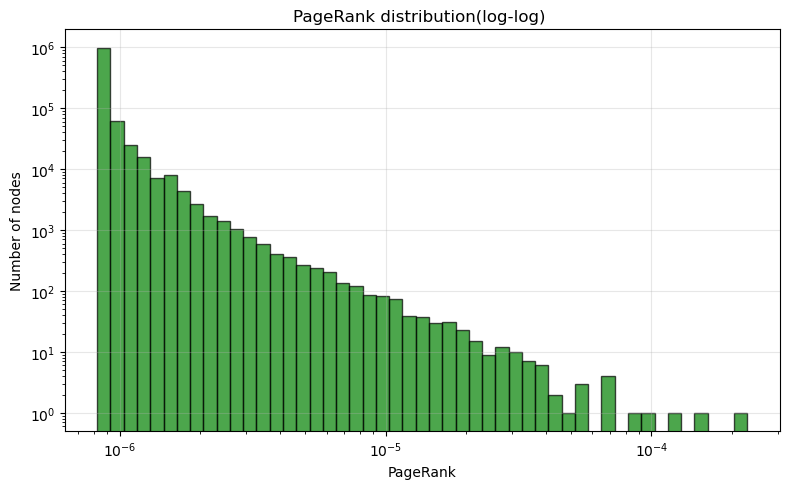

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================
# PLOT PAGERANK DISTRIBUTION (log-log)
# =============================================
pr_values = list(pr.values())

fig, ax = plt.subplots(figsize=(8, 5))

# Bin logaritmici
pr_values_nonzero = [v for v in pr_values if v > 0]
bins_pr = np.logspace(np.log10(min(pr_values_nonzero)), np.log10(max(pr_values_nonzero)), 50)
ax.hist(pr_values_nonzero, bins=bins_pr, edgecolor='black', alpha=0.7, color='green')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('PageRank')
ax.set_ylabel('Number of nodes')
ax.set_title('PageRank distribution(log-log) ')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pagerank_distribution_loglog.png', dpi=150)
plt.show()

## 5) HITS (hub e authority)

- `nx.hits(G)` restituisce due dizionari: **hubs** e **authorities**.
- Anche questo è **iterativo**.

**Costo:** ~O(k·|E|)  
Su grafi grandi può essere costoso e talvolta più instabile di PageRank.

In [6]:
hubs, auth = nx.hits(G, max_iter=1000, tol=1e-8)

top_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:10]
top_auth = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:10]

top_hubs, top_auth

([(1296087183, 0.0016441063217274444),
  (1353291112, 0.0016438643012409548),
  (1489529243, 0.0016432882456483445),
  (1343638843, 0.0016423058512385555),
  (1265080114, 0.0016423003485455815),
  (1450000704, 0.0016421384204552301),
  (1254793878, 0.001640756892384719),
  (1303844417, 0.001640331599725397),
  (1371199592, 0.0016400089827523735),
  (1424937539, 0.0016396911735837823)],
 [(1319837199, 0.001466093863644194),
  (1212645245, 0.001464074926052309),
  (1318275860, 0.0014618533192408052),
  (1461240728, 0.0014597384018712552),
  (1347229123, 0.0014581495257246738),
  (1215834055, 0.0014572565826898257),
  (1361322669, 0.001453538380371366),
  (1263113710, 0.0014521381295638327),
  (1444621361, 0.0014520848716576122),
  (1277748571, 0.0014515238471664966)])

## 6) Betweenness centrality (da usare con cautela)

- `nx.betweenness_centrality(G)` misura quanto un nodo fa da “ponte” tra percorsi.

**Costo:** ~O(|V|·|E|)  
👉 **Molto dispendioso**: sconsigliato su grafi grandi.

Suggerimento pratico: su grafi grandi considera un'**approssimazione** scegliendo un campione di sorgenti con `k=`.

In [ ]:
# ESEMPIO: su grafi grandi usare una versione approssimata:
approx_bc = nx.betweenness_centrality(G, k=100, seed=42)

#bc = nx.betweenness_centrality(G)  # ok solo su grafi piccoli/medi
sorted(approx_bc.items(), key=lambda x: x[1], reverse=True)[:10]

## 7) Closeness centrality (attenzione)

- `nx.closeness_centrality(G)` usa molte distanze minime.

**Costo:** ~O(|V|·(|V|+|E|))  
👉 **Dispendioso** su grafi grandi e poco robusto se il grafo non è ben connesso.

In [ ]:
cc = nx.closeness_centrality(G)
sorted(cc.items(), key=lambda x: x[1], reverse=True)[:10]

## 8) Distanze globali / all-pairs shortest paths (solo su sottografi)

- `nx.all_pairs_shortest_path_length(G)` calcola le distanze minime **da ogni nodo verso tutti i raggiungibili**.

**Costo:** ~O(|V|·(|V|+|E|))  
👉 **Impraticabile** su grafi grandi.

Consiglio: applicare la misura **solo alla SCC più grande**.

In [ ]:
# Costruiamo il sottografo della SCC più grande (tipica scelta)
H = G.subgraph(largest_scc).copy()

# ATTENZIONE: anche su H può essere costoso se H è grande
all_pairs = dict(nx.all_pairs_shortest_path_length(H))

# Esempio: media delle distanze (incluse le 0 su se stessi)
dists = []
for u, dist_dict in all_pairs.items():
    dists.extend(dist_dict.values())

avg_dist = sum(dists) / len(dists) if dists else None
len(H), avg_dist

## 9) Cicli e DAG

- `nx.is_directed_acyclic_graph(G)` verifica se il grafo è un **DAG** (nessun ciclo diretto).  
  **Costo:** ~O(|V|+|E|)

- `nx.simple_cycles(G)` elenca i cicli semplici.  
  **Costo:** potenzialmente **esponenziale** 👉 evitare su grafi grandi.

In [2]:
is_dag = nx.is_directed_acyclic_graph(G)
is_dag

False

In [ ]:
# ATTENZIONE: può esplodere su grafi grandi
cycles = list(nx.simple_cycles(G))
cycles

## 10) Reciprocità (utile e leggera)

Misura quanto gli archi sono spesso **bidirezionali**.

- `nx.reciprocity(G)` -> valore globale (0..1 circa)

**Costo:** ~O(|E|) (molto fattibile)

In [2]:
nx.reciprocity(G)

0.11127209454496204

In [9]:
# =============================================
# TELEGRAM LINKS FOR MANUAL INVESTIGATION
# =============================================
# This block provides channel IDs for manual investigation.
# 
# Note: Telegram channel_ids cannot be directly converted to links.
# To investigate, you need to either:
# 1. Use Telegram API (telethon/pyrogram) to get username/title from ID
# 2. Search the ID on sites like tgstat.com or similar

# ---- Define top 20 for each metric ----
# top20_pagerank: list of tuples [(node_id, score), ...]
# Example: [(1004035975, 0.00132), (1064404455, 0.00118), ...]
top20_pagerank = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
top20_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:20]
top20_authorities = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:20]

# ---- Extract just the node IDs as sets (for comparison later) ----
# Example: {1004035975, 1064404455, 1433940064, ...}
top20_pagerank_ids = set([node_id for node_id, score in top20_pagerank])
top20_hub_ids = set([node_id for node_id, score in top20_hubs])
top20_authority_ids = set([node_id for node_id, score in top20_authorities])

print("=" * 70)
print("CHANNEL IDs FOR MANUAL INVESTIGATION")
print("=" * 70)

print("\nNote: Telegram channel_ids are numeric and cannot be directly")
print("converted to links without using the Telegram API.")
print("\nTo investigate these channels, you can:")
print("  1. Use Telegram API (telethon) to get username/title from ID")
print("  2. Search the ID on tgstat.com or similar services")
print("  3. Use a bot like @username_to_id_bot (reverse lookup)")

# ---- Top 10 PageRank IDs ----
print("\n--- TOP 10 PAGERANK (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_pagerank[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Top 10 Hub IDs ----
print("\n--- TOP 10 HUBS (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_hubs[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Top 10 Authority IDs ----
print("\n--- TOP 10 AUTHORITIES (to investigate) ---")
for rank, (node_id, score) in enumerate(top20_authorities[:10], 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"  {rank}. Channel ID: {node_id} (in:{node_in_degree}, out:{node_out_degree})")

# ---- Summary of unique channels to investigate ----
all_top_ids = top20_pagerank_ids | top20_hub_ids | top20_authority_ids
print(f"\n--- SUMMARY ---")
print(f"Total unique channels in top 20 of any metric: {len(all_top_ids)}")

CHANNEL IDs FOR MANUAL INVESTIGATION

Note: Telegram channel_ids are numeric and cannot be directly
converted to links without using the Telegram API.

To investigate these channels, you can:
  1. Use Telegram API (telethon) to get username/title from ID
  2. Search the ID on tgstat.com or similar services
  3. Use a bot like @username_to_id_bot (reverse lookup)

--- TOP 10 PAGERANK (to investigate) ---
  1. Channel ID: 200389711 (in:0, out:4808)
  2. Channel ID: 191243967 (in:0, out:3631)
  3. Channel ID: 1117628569 (in:15, out:5740)
  4. Channel ID: 1394050290 (in:2, out:6172)
  5. Channel ID: 1101170442 (in:0, out:5601)
  6. Channel ID: 1096463945 (in:838, out:4194)
  7. Channel ID: 1139528163 (in:0, out:2658)
  8. Channel ID: 1001766948 (in:45, out:2692)
  9. Channel ID: 1009232144 (in:40, out:2941)
  10. Channel ID: 1378813139 (in:0, out:3759)

--- TOP 10 HUBS (to investigate) ---
  1. Channel ID: 1296087183 (in:126, out:1032)
  2. Channel ID: 1353291112 (in:437, out:1015)
  3. Ch

In [10]:
# =============================================
# MANUAL INVESTIGATION: TOP NODES BY PAGERANK, HUB, AUTHORITY
# =============================================
# This block prints detailed tables and compares overlap between metrics.
# Goal: understand if top Hubs are also top Authorities, or if they differ.
# 
# Reminder (in this graph, edge A→B means B forwarded from A):
# - Hub: node whose content is forwarded a lot (high out-degree)
# - Authority: node that forwards from many good sources (high in-degree)

# =============================================
# CONFIGURATION: Set how many top nodes to analyze
# =============================================
TOP_N = 700  # ← CHANGE THIS VALUE TO ANALYZE MORE OR FEWER NODES

# ---- Define top N for each metric ----
# top_n_pagerank: list of tuples [(node_id, score), ...]
# Example: [(1004035975, 0.00132), (1064404455, 0.00118), ...]
top_n_pagerank = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_n_hubs = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:TOP_N]
top_n_authorities = sorted(auth.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

# ---- Extract just the node IDs as sets (for comparison) ----
# Example: {1004035975, 1064404455, 1433940064, ...}
top_n_pagerank_ids = set([node_id for node_id, score in top_n_pagerank])
top_n_hub_ids = set([node_id for node_id, score in top_n_hubs])
top_n_authority_ids = set([node_id for node_id, score in top_n_authorities])

print("=" * 70)
print(f"TOP {TOP_N} NODES BY PAGERANK, HUB, AUTHORITY")
print("=" * 70)

# ---- Print top N PageRank with in/out degree ----
print(f"\n--- TOP {TOP_N} PAGERANK ---")
print(f"{'Rank':<5} {'Node ID':<15} {'PageRank':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_pagerank, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# ---- Print top N Hubs with in/out degree ----
print(f"\n--- TOP {TOP_N} HUBS ---")
print(f"{'Rank':<5} {'Node ID':<15} {'Hub Score':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_hubs, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# ---- Print top N Authorities with in/out degree ----
print(f"\n--- TOP {TOP_N} AUTHORITIES ---")
print(f"{'Rank':<5} {'Node ID':<15} {'Auth Score':<12} {'In-degree':<12} {'Out-degree':<12}")
print("-" * 56)
for rank, (node_id, score) in enumerate(top_n_authorities, 1):
    node_in_degree = in_deg.get(node_id, 0)
    node_out_degree = out_deg.get(node_id, 0)
    print(f"{rank:<5} {node_id:<15} {score:<12.6f} {node_in_degree:<12} {node_out_degree:<12}")

# =============================================
# COMPARISON: Are top Hubs also top Authorities?
# =============================================
print("\n" + "=" * 70)
print(f"COMPARISON: TOP {TOP_N} HUBS vs TOP {TOP_N} AUTHORITIES")
print("=" * 70)

# Set operations to find overlap and differences
nodes_in_both_hub_and_auth = top_n_hub_ids & top_n_authority_ids  # intersection
nodes_only_in_hub = top_n_hub_ids - top_n_authority_ids           # hub but not authority
nodes_only_in_auth = top_n_authority_ids - top_n_hub_ids          # authority but not hub

print(f"\nNodes in BOTH top {TOP_N} (Hub AND Authority): {len(nodes_in_both_hub_and_auth)}")
print(f"Nodes ONLY in top {TOP_N} Hubs: {len(nodes_only_in_hub)}")
print(f"Nodes ONLY in top {TOP_N} Authorities: {len(nodes_only_in_auth)}")

if len(nodes_in_both_hub_and_auth) > 0:
    print(f"\nNode IDs in common: {nodes_in_both_hub_and_auth}")
else:
    print(f"\n→ Top {TOP_N} Hubs and top {TOP_N} Authorities are DISTINCT groups!")

# ---- Comparison across all three metrics ----
print("\n" + "=" * 70)
print(f"COMPARISON: PAGERANK vs HUB vs AUTHORITY (TOP {TOP_N})")
print("=" * 70)

overlap_pr_hub = top_n_pagerank_ids & top_n_hub_ids
overlap_pr_auth = top_n_pagerank_ids & top_n_authority_ids
overlap_hub_auth = top_n_hub_ids & top_n_authority_ids
overlap_all_three = top_n_pagerank_ids & top_n_hub_ids & top_n_authority_ids

print(f"PageRank ∩ Hub: {len(overlap_pr_hub)} nodes in common")
print(f"PageRank ∩ Authority: {len(overlap_pr_auth)} nodes in common")
print(f"Hub ∩ Authority: {len(overlap_hub_auth)} nodes in common")
print(f"All three metrics: {len(overlap_all_three)} nodes in common")

if len(overlap_all_three) > 0:
    print(f"\nNodes in ALL three top {TOP_N}: {overlap_all_three}")

# ---- Summary ----
all_top_ids = top_n_pagerank_ids | top_n_hub_ids | top_n_authority_ids
print(f"\n--- SUMMARY ---")
print(f"Total unique channels in top {TOP_N} of any metric: {len(all_top_ids)}")

TOP 700 NODES BY PAGERANK, HUB, AUTHORITY

--- TOP 700 PAGERANK ---
Rank  Node ID         PageRank     In-degree    Out-degree  
--------------------------------------------------------
1     200389711       0.000230     0            4808        
2     191243967       0.000159     0            3631        
3     1117628569      0.000123     15           5740        
4     1394050290      0.000098     2            6172        
5     1101170442      0.000091     0            5601        
6     1096463945      0.000072     838          4194        
7     1139528163      0.000070     0            2658        
8     1001766948      0.000068     45           2692        
9     1009232144      0.000066     40           2941        
10    1378813139      0.000057     0            3759        
11    1036240821      0.000055     176          2937        
12    1069772626      0.000054     61           4269        
13    1203054640      0.000051     143          2324        
14    169297403      

In [11]:
# =============================================
# INVESTIGATE TOP NODES: PAGERANK, HUB, AUTHORITY
# =============================================
# This cell allows manual investigation of top channels.
# Shows preprocessing info (English message count) for each channel.
#
# Data structure example:
# channels_config = {
#     1004035975: {
#         'n_messages': 15,
#         'selection': 'random',
#         'metrics': ['pagerank', 'hub'],
#         'english_msg_count': 156,  # From preprocessing
#     },
# }

import json
import os
import random
from collections import defaultdict
from datetime import datetime

# =============================================
# CONFIGURATION
# =============================================
TGDATASET_DIR = "../../material"
EXTRACTED_DIR = f"{TGDATASET_DIR}/TGDataset_extracted"
MAPPING_FILE = f"{TGDATASET_DIR}/channel_file_mapping.json"
LABELED_FILE = f"{TGDATASET_DIR}/TGDataset/labeled_data/ch_to_topic_mapping.csv"

# How many top nodes to investigate for each metric
TOP_N_TO_INVESTIGATE = 10

# How many messages to extract per channel
N_MESSAGES = 15

# Selection mode: 'first', 'last', 'random'
SELECTION_MODE = 'random'

# =============================================
# BUILD CHANNELS CONFIG DICTIONARY
# =============================================
# Structure: {channel_id: {'n_messages': int, 'selection': str, 'metrics': list, ...}}
channels_config = {}

# Add top PageRank nodes
for rank, (node_id, score) in enumerate(top_n_pagerank[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),  # From preprocessing
        }
    channels_config[node_id]['metrics'].append('pagerank')
    channels_config[node_id]['pagerank_rank'] = rank
    channels_config[node_id]['pagerank_score'] = score

# Add top Hub nodes
for rank, (node_id, score) in enumerate(top_n_hubs[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),
        }
    channels_config[node_id]['metrics'].append('hub')
    channels_config[node_id]['hub_rank'] = rank
    channels_config[node_id]['hub_score'] = score

# Add top Authority nodes
for rank, (node_id, score) in enumerate(top_n_authorities[:TOP_N_TO_INVESTIGATE], 1):
    if node_id not in channels_config:
        channels_config[node_id] = {
            'n_messages': N_MESSAGES,
            'selection': SELECTION_MODE,
            'metrics': [],
            'in_degree': in_deg.get(node_id, 0),
            'out_degree': out_deg.get(node_id, 0),
            'english_msg_count': channel_english_count.get(node_id, 0),
        }
    channels_config[node_id]['metrics'].append('authority')
    channels_config[node_id]['authority_rank'] = rank
    channels_config[node_id]['authority_score'] = score

print(f"Channels to investigate: {len(channels_config)}")
print(f"  - From PageRank top {TOP_N_TO_INVESTIGATE}")
print(f"  - From Hub top {TOP_N_TO_INVESTIGATE}")
print(f"  - From Authority top {TOP_N_TO_INVESTIGATE}")

# =============================================
# LOAD CHANNEL MAPPING AND LABELS
# =============================================
print("\nLoading channel mapping...")
with open(MAPPING_FILE, 'r') as f:
    channel_mapping = json.load(f)

print("Loading ground truth labels...")
labels_df = pd.read_csv(LABELED_FILE)
channel_labels = dict(zip(labels_df['ch_ID'], labels_df['topic']))

print(f"  Channels in mapping: {len(channel_mapping):,}")
print(f"  Channels with labels: {len(channel_labels):,}")

# =============================================
# FUNCTION: LOAD CHANNEL DATA FROM TGDATASET
# =============================================
def load_channel_data(channel_id, channel_mapping, extracted_dir):
    """
    Load channel data from TGDataset extracted files.
    
    Returns dict with keys: 'title', 'username', 'text_messages', 'total_messages'
    """
    ch_id_str = str(channel_id)
    
    if ch_id_str not in channel_mapping:
        return None
    
    file_path = channel_mapping[ch_id_str]['file']
    full_path = f"{extracted_dir}/{file_path}"
    
    if not os.path.exists(full_path):
        return None
    
    try:
        with open(full_path, 'r') as f:
            data = json.load(f)
        
        if ch_id_str in data:
            channel_data = data[ch_id_str]
            return {
                'title': channel_data.get('title', '[no title]'),
                'username': channel_data.get('username', '[no username]'),
                'text_messages': channel_data.get('text_messages', {}),
                'total_messages': len(channel_data.get('text_messages', {})),
            }
    except Exception as e:
        print(f"  [ERROR] Failed to load channel {channel_id}: {e}")
    
    return None

# =============================================
# FUNCTION: SELECT MESSAGES
# =============================================
def select_messages(text_messages, n_messages, selection_mode):
    """
    Select messages from a channel based on configuration.
    Returns list of (msg_id, msg_data) tuples, sorted by date.
    """
    if not text_messages:
        return []
    
    msg_items = list(text_messages.items())
    msg_items_sorted = sorted(msg_items, key=lambda x: x[1].get('date', 0))
    
    n_available = len(msg_items_sorted)
    n_to_select = min(n_messages, n_available)
    
    if selection_mode == 'first':
        selected = msg_items_sorted[:n_to_select]
    elif selection_mode == 'last':
        selected = msg_items_sorted[-n_to_select:]
    elif selection_mode == 'random':
        selected = random.sample(msg_items_sorted, n_to_select)
        selected = sorted(selected, key=lambda x: x[1].get('date', 0))
    else:
        selected = msg_items_sorted[:n_to_select]
    
    return selected

# =============================================
# INVESTIGATE EACH CHANNEL
# =============================================
print("\n" + "=" * 80)
print("CHANNEL INVESTIGATION")
print("=" * 80)

investigation_results = {}

for channel_id, config in channels_config.items():
    print(f"\n{'─' * 80}")
    
    # Header with metrics
    metrics_str = ', '.join(config['metrics']).upper()
    print(f"CHANNEL {channel_id} [{metrics_str}]")
    print(f"{'─' * 80}")
    
    # Print metric rankings
    for metric in config['metrics']:
        rank = config.get(f'{metric}_rank', '?')
        score = config.get(f'{metric}_score', 0)
        print(f"  {metric.capitalize()}: Rank #{rank}, Score: {score:.6f}")
    
    # Print degree info
    print(f"  In-degree: {config['in_degree']:,}")
    print(f"  Out-degree: {config['out_degree']:,}")
    
    # Print preprocessing info
    english_count = config['english_msg_count']
    preprocess_status = "✓ VALID" if english_count >= MIN_CHANNEL_MESSAGES else f"✗ INVALID (< {MIN_CHANNEL_MESSAGES})"
    print(f"  English messages: {english_count} {preprocess_status}")
    
    # Check if labeled
    gt_label = channel_labels.get(channel_id, '[NOT LABELED]')
    print(f"  Ground Truth Label: {gt_label}")
    
    # Load channel data
    channel_data = load_channel_data(channel_id, channel_mapping, EXTRACTED_DIR)
    
    if channel_data is None:
        print(f"  [WARNING] Channel not found in TGDataset")
        investigation_results[channel_id] = {
            'config': config,
            'label': gt_label,
            'found': False,
        }
        continue
    
    print(f"  Title: {channel_data['title']}")
    print(f"  Username: @{channel_data['username']}")
    print(f"  Total messages in dataset: {channel_data['total_messages']:,}")
    
    # Select messages
    selected_messages = select_messages(
        channel_data['text_messages'],
        config['n_messages'],
        config['selection']
    )
    
    print(f"\n  MESSAGES ({len(selected_messages)} {config['selection']}, max {config['n_messages']}):")
    print(f"  {'─' * 70}")
    
    for msg_id, msg_data in selected_messages:
        msg_text = msg_data.get('message', '[no text]')
        msg_date = msg_data.get('date', 0)
        fwd_from = msg_data.get('forwarded_from_id', None)
        
        # Format date
        if msg_date:
            date_str = datetime.fromtimestamp(msg_date).strftime('%Y-%m-%d %H:%M')
        else:
            date_str = '[no date]'
        
        # Truncate message
        msg_display = msg_text[:300] if msg_text else '[empty]'
        if len(msg_text) > 300:
            msg_display += "..."
        
        # Forward indicator
        fwd_str = f" [FWD from {fwd_from}]" if fwd_from else ""
        
        print(f"    [{date_str}]{fwd_str}")
        print(f"    {msg_display}")
        print()
    
    # Store results
    investigation_results[channel_id] = {
        'config': config,
        'label': gt_label,
        'found': True,
        'title': channel_data['title'],
        'username': channel_data['username'],
        'total_messages': channel_data['total_messages'],
        'english_msg_count': english_count,
    }

# =============================================
# SUMMARY
# =============================================
print("\n" + "=" * 80)
print("INVESTIGATION SUMMARY")
print("=" * 80)

found_count = sum(1 for r in investigation_results.values() if r['found'])
labeled_count = sum(1 for r in investigation_results.values() if r['label'] != '[NOT LABELED]')

print(f"\nChannels investigated: {len(investigation_results)}")
print(f"  Found in TGDataset: {found_count}")
print(f"  Not found: {len(investigation_results) - found_count}")
print(f"  With GT label: {labeled_count}")

# Preprocessing status
valid_count = sum(1 for ch_id, r in investigation_results.items() 
                  if channels_config[ch_id]['english_msg_count'] >= MIN_CHANNEL_MESSAGES)
print(f"  Valid (>= {MIN_CHANNEL_MESSAGES} English msgs): {valid_count}")
print(f"  Invalid (< {MIN_CHANNEL_MESSAGES} English msgs): {len(investigation_results) - valid_count}")

# By metric
print("\nBy metric:")
for metric in ['pagerank', 'hub', 'authority']:
    count = sum(1 for ch_id, r in investigation_results.items() 
                if metric in channels_config[ch_id]['metrics'])
    print(f"  {metric.capitalize()}: {count} channels")
```

---

## Cambiamenti Cella 33

| Prima | Dopo |
|-------|------|
| Nessuna info preprocessing | Mostra `english_msg_count` per ogni canale |
| Nessuno status validità | Mostra `✓ VALID` o `✗ INVALID (< 10)` |
| Nessun summary preprocessing | Summary con conteggio valid/invalid |

---

## Output esempio (nuovo)
```
────────────────────────────────────────────────────────────────────────────────
CHANNEL 1117628569 [PAGERANK]
────────────────────────────────────────────────────────────────────────────────
  Pagerank: Rank #3, Score: 0.000123
  In-degree: 15
  Out-degree: 5,740
  English messages: 156 ✓ VALID
  Ground Truth Label: [NOT LABELED]
  Title: Mash
  Username: @breakingmash
  ...

Channels to investigate: 30
  - From PageRank top 10
  - From Hub top 10
  - From Authority top 10

Loading channel mapping...
Loading ground truth labels...
  Channels in mapping: 120,979
  Channels with labels: 19,768

CHANNEL INVESTIGATION

────────────────────────────────────────────────────────────────────────────────
CHANNEL 200389711 [PAGERANK]
────────────────────────────────────────────────────────────────────────────────
  Pagerank: Rank #1, Score: 0.000230
  In-degree: 0
  Out-degree: 4,808
  Ground Truth Label: [NOT LABELED]
  [WARNING] Channel not found in TGDataset

────────────────────────────────────────────────────────────────────────────────
CHANNEL 191243967 [PAGERANK]
────────────────────────────────────────────────────────────────────────────────
  Pagerank: Rank #2, Score: 0.000159
  In-degree: 0
  Out-degree: 3,631
  Ground Truth Label: [NOT LABELED]
  [WARNING] Channel not found in TGDataset

──────────────────────────────────────────────────────────────────────

## Riepilogo pratico (cosa usare su grafi grandi)

✅ **Sempre ok**: nodi/archi/densità, in/out-degree, SCC/WCC, reciprocità  
⚠️ **Ok con attenzione**: PageRank, HITS (iterativi)  
❌ **Spesso da evitare**: betweenness, closeness, all-pairs shortest paths, enumerazione cicli
